# Fit inspection

Visual QA of a fitted spectrum plus a parameter table with uncertainties.
All functions live in `alibz.inspection` and are exported from `alibz`:

| Function | Purpose |
|---|---|
| `plot_spectrum_overview(x, y, fit_dict, xlim=..., log_scale=...)` | raw + background, fit + peak locations, residual vs ±2σ local-noise band |
| `plot_peak_zoom(x, y, fit_dict, center_nm, span_nm=...)` | one peak: data, own component, other components, residual, parameters ± σ |
| `peak_table(x, y, fit_dict)` / `format_peak_table(rows)` | per-peak center/area/σ/γ ± 1σ, FWHM, height, S/N |
| `estimate_peak_uncertainties(x, y_bgsub, peaks)` | the underlying joint-GLS blend-group σ's |

**Reading the uncertainties:** blended peaks carry honestly inflated σ
(joint covariance per blend group); parameters at a zero bound show
`(pinned)`; for strong isolated lines σ is a statistical lower bound —
the pipeline's empirical scatter can exceed it several-fold (documented
in the docstring and pinned by `tests/test_inspection.py`).

In [1]:
%matplotlib inline
import numpy as np
from alibz import (PeakyFinder, peak_table, format_peak_table,
                   plot_spectrum_overview, plot_peak_zoom)

PATH = '/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/'
SPECTRUM = 0

finder = PeakyFinder(PATH)
finder.data.load_data()
x, y = finder.data.get_data()[SPECTRUM]
fit = finder.fit_spectrum(x, y, subtract_background=True, plot=False, n_sigma=0)
print(f"{fit['sorted_parameter_array'].shape[0]} peaks fitted")

303 peaks fitted


## Full-spectrum overview
Raw + background, fitted model with peak locations, and the residual against the ±2σ local-noise band (structure outside the band = real misfit).

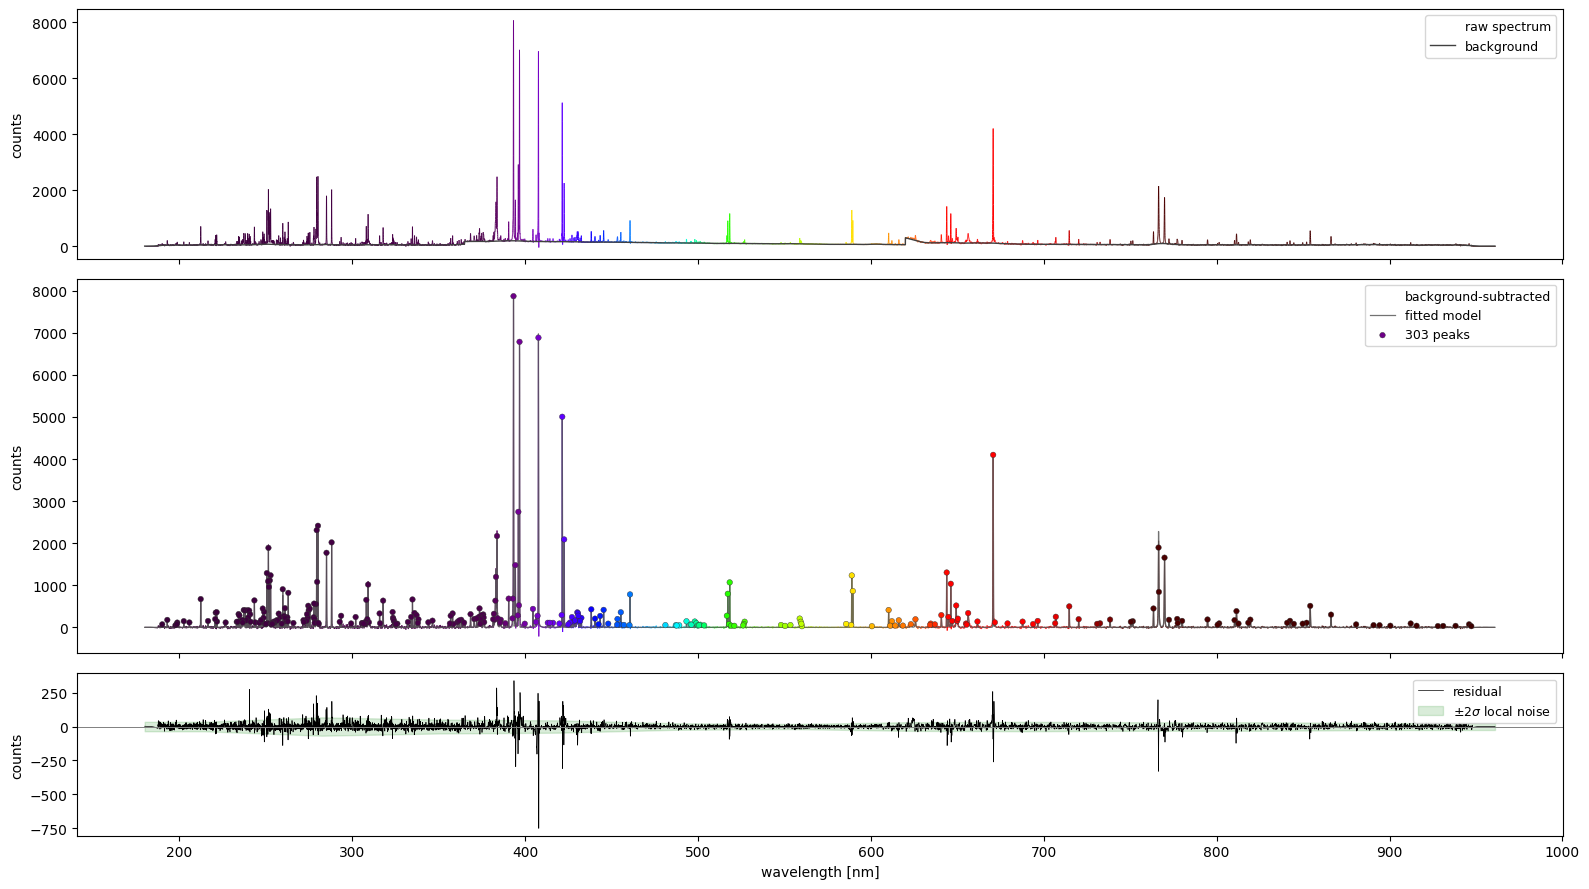

In [2]:
fig, axs = plot_spectrum_overview(x, y, fit)

## Zoom into a region
Same three panels, windowed — e.g. the Ca II H&K region.

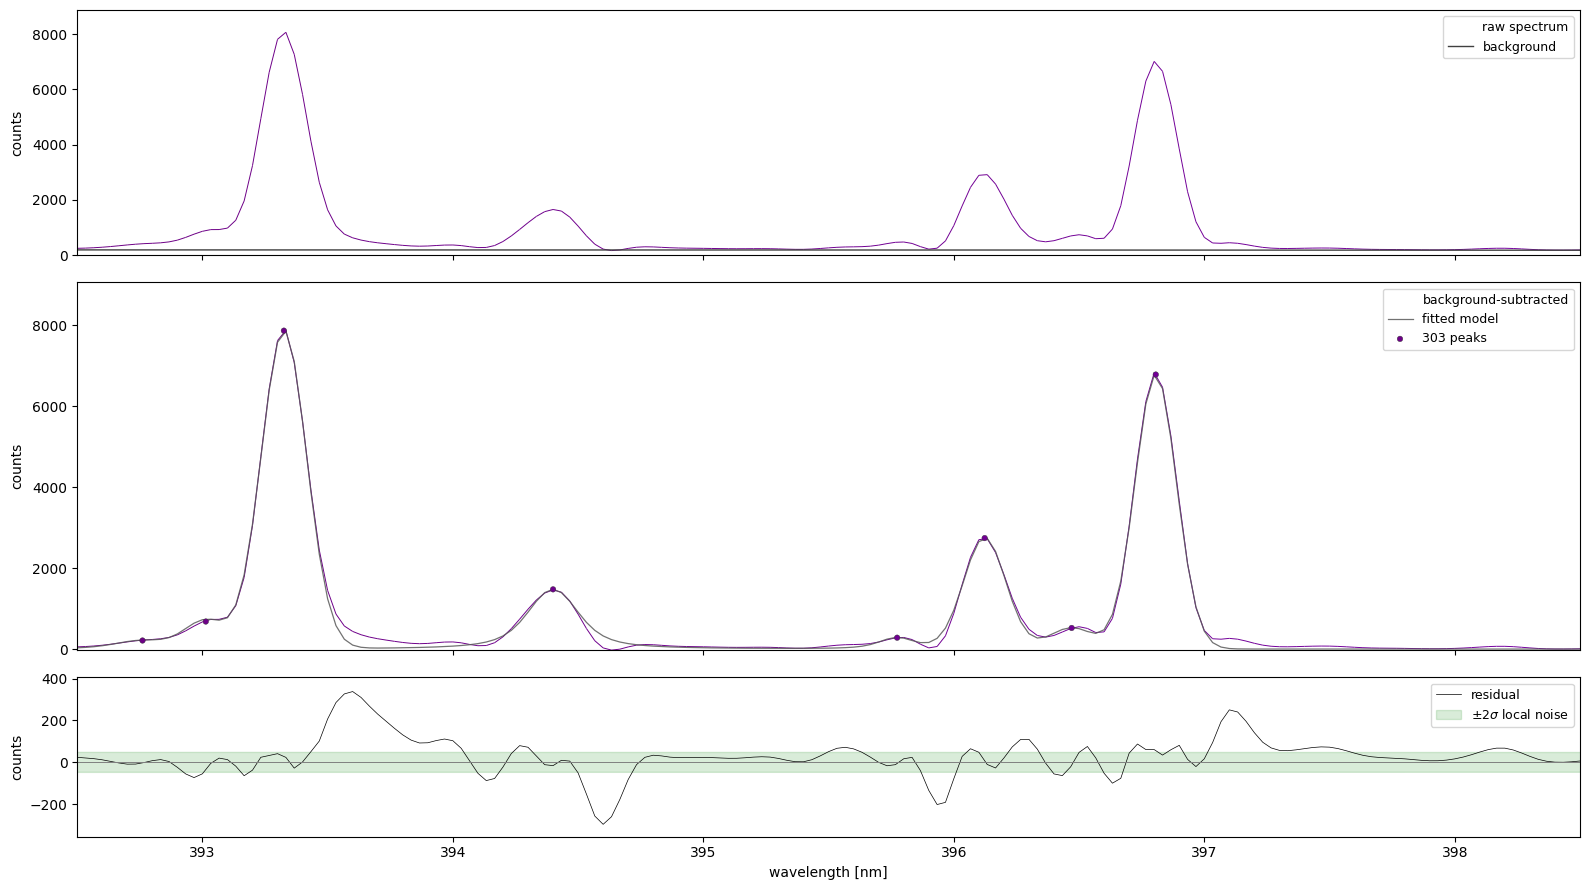

In [3]:
fig, axs = plot_spectrum_overview(x, y, fit, xlim=(392.5, 398.5))

## Single-peak inspection
Data, this peak's Voigt component, everything else, and the residual —
with fitted parameters ± uncertainties in the title.  On Li I 670.8 the
S-shaped residual outside the noise band is the self-absorption
signature (flat-topped core, suppressed wings).

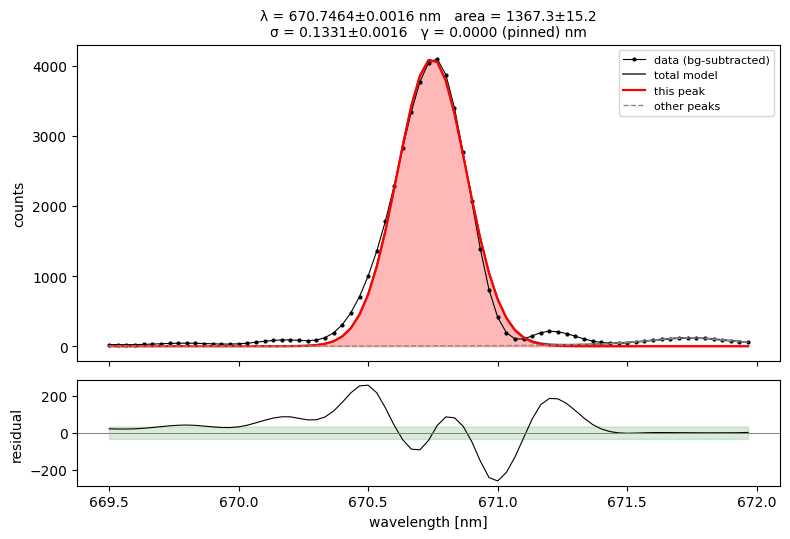

In [4]:
fig, axs = plot_peak_zoom(x, y, fit, 670.78, span_nm=2.5)

## Parameter table with uncertainties
Strongest peaks first (`sort_by="center"` for wavelength order).  Note
the K I 766.5 split components carrying honestly blend-inflated errors,
and `(pinned)` marking bound-constrained parameters.

In [5]:
rows = peak_table(x, y, fit)
print(format_peak_table(rows, max_rows=25))

             center [nm]                   area             sigma [nm]             gamma [nm]    FWHM    height     S/N
  393.3254 +/-    0.0010    1786.2 +/-     19.9     0.0905 +/-  0.0011        0.0000 (pinned)   0.213    7871.2   330.3
  407.7485 +/-    0.0009    1441.2 +/-     19.7     0.0835 +/-  0.0011        0.0000 (pinned)   0.197    6884.1   296.1
  396.8063 +/-    0.0009    1409.3 +/-     12.9     0.0828 +/-  0.0009        0.0000 (pinned)   0.195    6786.3   286.5
  670.7464 +/-    0.0016    1367.3 +/-     15.2     0.1331 +/-  0.0016        0.0000 (pinned)   0.313    4099.6   242.2
  421.5220 +/-    0.0010     975.8 +/-     11.0     0.0778 +/-  0.0010        0.0000 (pinned)   0.183    5005.2   223.5
  769.8684 +/-    0.0020     764.2 +/-     13.5     0.0802 +/-  0.0078     0.1101 +/-  0.0078   0.333    1656.4   105.8
  383.7929 +/-    0.0024     634.3 +/-     37.3     0.0722 +/-  0.0120     0.0503 +/-  0.0173   0.230    2170.4    89.7
  396.1233 +/-    0.0022     577.8 +/-  

The rows are plain dicts, so filtering and export are one-liners:

```python
suspicious = [r for r in rows if r["snr"] < 15 or r["fwhm_nm"] > 0.5]
import csv
with open("peaks.csv", "w") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys()); w.writeheader(); w.writerows(rows)
```

## Second-iteration refinement: blends vs self-absorption asymmetry

The first pass fits every feature with symmetric Voigts, so it has two failure
modes on real spectra:

- a **self-absorbed line** (flat top or red/blue shading) gets split into two
  *phantom* components — e.g. K I 766.49 fitted as 766.40 + 766.61;
- a **genuine blend** narrower than one FWHM gets fitted as a single peak.

`refine_fit` re-examines every ambiguous feature (sub-FWHM component pairs and
significant residual structure) under three local models — single Voigt (S),
self-absorption-attenuated Voigt (A), two Voigts (B) — compared by
noise-rescaled BIC and **gated by physics**: a blend verdict needs two distinct
database lines matching the fitted centers with consistent separation; an
asymmetric verdict is only *applied* when the primary line has a
resonance-capable lower level (the class that self-absorbs).

In [6]:
from alibz import refine_fit
from alibz.utils.database import Database
from alibz.utils.wavelength import estimate_wavelength_shift

db = Database("db")
shift, n_anchor = estimate_wavelength_shift(fit["sorted_parameter_array"], db)
refined, decisions = refine_fit(x, y, fit, db=db, shift_nm=shift)

from collections import Counter
print(f"shift {1000*shift:+.1f} pm ({n_anchor} anchors)")
print(f"{fit['sorted_parameter_array'].shape[0]} -> "
      f"{refined['sorted_parameter_array'].shape[0]} peaks")
print("verdicts:", dict(Counter(d['verdict'] for d in decisions)))
print("actions: ", dict(Counter(d['action'] for d in decisions)))

shift -14.9 pm (15 anchors)
303 -> 291 peaks
verdicts: {'blend': 4, 'asymmetric': 11, 'ambiguous': 23, 'asymmetric-displaced': 11, 'single': 6, 'asymmetric-nonresonant': 9}
actions:  {'split': 4, 'sa-tag': 11, 'none': 46, 'merge': 3}


In [7]:
for d in sorted(decisions, key=lambda d: d["center"]):
    if d["action"] == "none":
        continue
    extra = ""
    if "tau_a" in d:
        extra = (f"  tau={d['tau_a']:.2f} delta={1000*d['delta_nm']:+.0f} pm"
                 f"  emission={d['emission_area']:.3g} observed={d['observed_area']:.3g}")
    print(f"{d['center']:9.3f}  {d['kind']:8s} {d['verdict']:18s} {d['action']:5s}"
          f"{'  resonance' if d['resonance_primary'] else ''}{extra}")

  198.789  pair     asymmetric         sa-tag  resonance  tau=3.41 delta=-14 pm  emission=183 observed=41.3
  251.692  pair     blend              split  resonance
  254.237  pair     asymmetric         sa-tag  resonance  tau=3.57 delta=-1 pm  emission=198 observed=30.2
  261.203  pair     asymmetric         sa-tag  resonance  tau=3.30 delta=+18 pm  emission=465 observed=75.5
  271.935  pair     asymmetric         sa-tag  resonance  tau=3.12 delta=+11 pm  emission=206 observed=38.1
  278.193  pair     single             merge
  280.239  pair     asymmetric         sa-tag  resonance  tau=0.58 delta=-28 pm  emission=760 observed=565
  309.441  pair     blend              split
  374.777  pair     asymmetric         sa-tag  resonance  tau=3.51 delta=-20 pm  emission=716 observed=108
  393.302  pair     blend              split  resonance
  396.781  pair     blend              split  resonance
  518.367  residual asymmetric         sa-tag  resonance  tau=0.65 delta=+3 pm  emission=427 obse

### K I 766.5: phantom split merged

The first pass fits the flat-topped K I resonance line as two components; the
refinement recognizes the pair as ONE self-absorbed line (model A beats two
free Voigts after the parsimony penalty, and the K I resonance physics
corroborates) and merges it. Left: first-pass fit; right: refined.

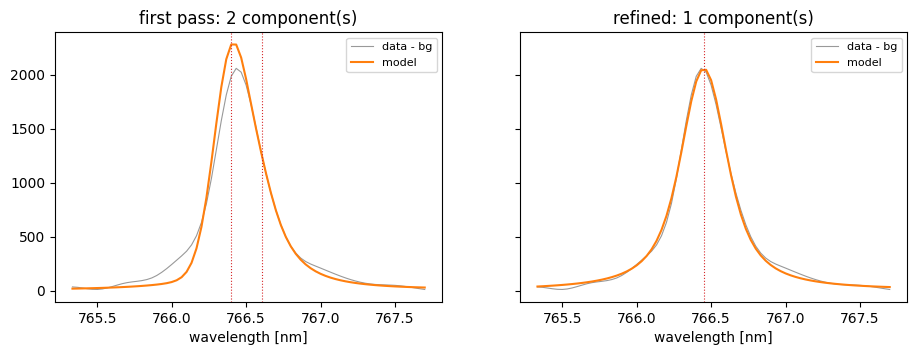

In [8]:
import matplotlib.pyplot as plt
from alibz.utils.voigt import multi_voigt

def compare_zoom(center, span=1.2):
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
    m = (x > center - span) & (x < center + span)
    bg = fit["background"]
    for ax, f, title in ((axs[0], fit, "first pass"), (axs[1], refined, "refined")):
        pk = f["sorted_parameter_array"]
        ax.plot(x[m], (y - bg)[m], color="0.6", lw=0.8, label="data - bg")
        ax.plot(x[m], multi_voigt(x[m], np.ravel(pk[:, :4])), "C1", label="model")
        near = pk[np.abs(pk[:, 1] - center) < span]
        for a, mu in near[:, :2]:
            ax.axvline(mu, color="C3", ls=":", lw=0.8)
        ax.set_title(f"{title}: {near.shape[0]} component(s)")
        ax.set_xlabel("wavelength [nm]")
        ax.legend(fontsize=8)
    return fig

compare_zoom(766.5);

### Li I 670.8: asymmetry quantified, not split

The Li I resonance doublet shows red-shaded self-absorption. The refinement
keeps ONE component but refits it with the attenuated model: the table row
carries the **observed** (attenuated) area so it stays consistent with every
other row, while the decision record reports the reconstructed unattenuated
emission area, the absorber optical depth `tau_a`, and the absorber shift
`delta`.

**Do not apply the indexer's downstream self-absorption correction on top of
rows merged this way** — the attenuation is already accounted for in the
decision record.

{'verdict': 'asymmetric', 'resonance_primary': True, 'kind': 'residual', 'action': 'sa-tag', 'emission_area': 2099.3563925877475, 'tau_a': 0.5766387899514943, 'delta_nm': -0.0547619754562441, 'observed_area': 1512.2828766350347}


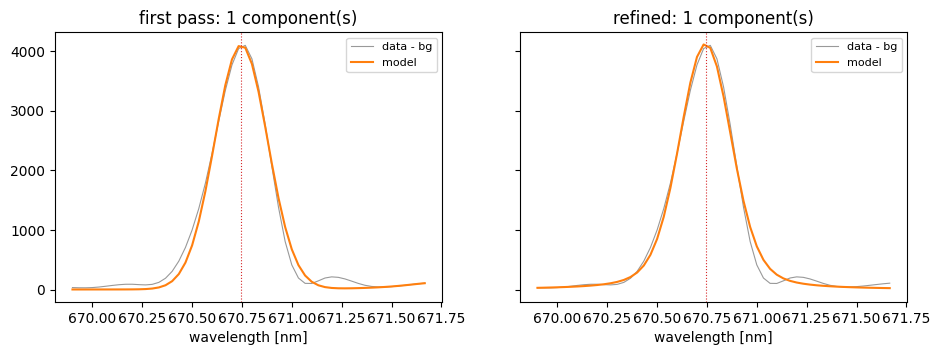

In [9]:
compare_zoom(670.78, span=0.9)
for d in decisions:
    if abs(d["center"] - 670.78) < 0.2:
        print({k: v for k, v in d.items()
               if k in ("kind", "verdict", "action", "tau_a", "delta_nm",
                        "emission_area", "observed_area", "resonance_primary")})

## Prior-driven minor lines from established elements

Once the strong lines establish which elements are present, every *other*
line of an element is predicted: within one ion stage the Boltzmann factor
`gA·exp(-Ek/kT)` fixes all line ratios up to a single per-(element, stage)
area **scale**, measured from that stage's clean strong lines. Those
predictions let `seed_minor_lines`

1. fit low-intensity lines the blind pass rejected — "an established
   element's line belongs *exactly here, this strong*" justifies a
   detection threshold well below the blind 3–5σ;
2. **deblend** established lines — a minor line of one element hidden under
   a stronger line of another is fitted jointly (center pinned at the db
   position) and the strong line's contamination is reported.

Trust gates keep an *absent* element from inventing lines: a stage needs ≥3
consistent references, and is **falsified** if its own strongest line would
be far brighter than anything actually matched (a spurious Na II built from
faint coincidences, which predicts 10⁵-count resonance lines that aren't
there, is rejected outright). Every addition must also agree with its
Boltzmann prediction to within a factor of ~5, or it is recorded as
`inconsistent`/`missing` rather than added.

In [10]:
from alibz import seed_minor_lines
from alibz.minor_lines import match_and_scale
from alibz.pipeline import element_block_color, element_sort_key

# established elements (from the full-corpus composition)
ELEMENTS = sorted(["K", "Si", "Ca", "Na", "Al", "Li", "Fe", "Rb", "Cs", "Sr",
                   "Mg", "Mn", "Ba", "H", "O", "N", "C"],
                  key=element_sort_key)

scales, matched = match_and_scale(refined["sorted_parameter_array"], db,
                                  ELEMENTS, shift_nm=shift,
                                  x_range=(float(x[0]), float(x[-1])))
final, records = seed_minor_lines(x, y, refined, db, ELEMENTS, shift_nm=shift)

from collections import Counter
print(f"{refined['sorted_parameter_array'].shape[0]} -> "
      f"{final['sorted_parameter_array'].shape[0]} peaks")
print("actions:", dict(Counter(r['action'] for r in records)))

291 -> 301 peaks
actions: {'missing': 12, 'added': 10, 'inconsistent': 25, 'rejected': 33}


In [11]:
print("added minor lines:")
for r in sorted([r for r in records if r["action"] == "added"],
                key=lambda r: r["wavelength_db"]):
    n_int = len(r.get("interference", []))
    print(f"  {r['element']:2s} {'I' if r['stage']==1 else 'II':3s} "
          f"{r['wavelength_db']:9.3f}  expected={r['expected_area']:7.1f} "
          f"fitted={r['area']:7.1f}  snr={r['snr']:5.1f}"
          + (f"  [{n_int} interference]" if n_int else ""))

print("\ninterference corrections on established lines (>2%):")
for r in records:
    for i in r.get("interference", []):
        if abs(i["change"]) > 0.02:
            print(f"  {r['element']:2s} {r['wavelength_db']:9.3f} -> "
                  f"{i['center']:9.3f}: {100*i['change']:+5.1f}% "
                  f"({i['area_before']:.0f} -> {i['area_after']:.0f})")

added minor lines:
  Si I     198.636  expected=   14.3 fitted=    8.8  snr=  5.8  [1 interference]
  Sr II    215.285  expected=   12.4 fitted=    8.1  snr=  5.0
  Al I     220.467  expected=   19.7 fitted=    9.9  snr=  5.3  [1 interference]
  Fe II    240.666  expected=   30.7 fitted=   36.3  snr= 18.2  [2 interference]
  Fe II    249.326  expected=   10.5 fitted=   14.1  snr=  6.8  [3 interference]
  Fe II    261.382  expected=   34.6 fitted=   23.4  snr=  9.6  [2 interference]
  Ca I     458.140  expected=   19.9 fitted=    7.2  snr=  4.5
  Ca I     518.884  expected=   24.1 fitted=    6.4  snr=  6.0  [2 interference]
  Ca I     558.197  expected=   10.8 fitted=    4.1  snr=  4.3
  Ca I     671.768  expected=   11.9 fitted=   22.7  snr= 11.8

interference corrections on established lines (>2%):
  Fe   261.382 ->   261.143: -14.0% (76 -> 65)
  Fe   261.382 ->   261.699: -16.1% (29 -> 24)
  Fe   240.666 ->   240.456:  -7.4% (49 -> 46)
  Fe   240.666 ->   241.032:  -2.3% (45 -> 44)
 

### Falsification in action: absent stages predict, and the data refuse

`match_and_scale` will build a scale for *any* element passed in, including
ones that aren't really there — a handful of its lines will coincide with
real peaks. The `missing` records are the audit trail: confident predictions
(expected SNR ≥ 10) that the spectrum refused. A stage producing many of
these is not present, and the falsification gate drops it before it can
inject phantoms.

In [12]:
missing = sorted([r for r in records if r["action"] == "missing"],
                 key=lambda r: -r["expected_snr"])[:10]
print("top confident predictions the data refused:")
for r in missing:
    print(f"  {r['element']:2s} {'I' if r['stage']==1 else 'II':3s} "
          f"{r['wavelength_db']:9.3f}  expected={r['expected_area']:10.1f} "
          f"exp_snr={r['expected_snr']:8.1f}  fitted={r.get('area', 0):6.1f}")

top confident predictions the data refused:
  Si I     185.067  expected=     152.6 exp_snr=    53.0  fitted=   0.0
  Fe II    259.940  expected=     213.0 exp_snr=    45.3  fitted=  61.8
  Si I     184.747  expected=      83.4 exp_snr=    29.0  fitted=   0.0
  Ca I     616.956  expected=      32.3 exp_snr=    22.7  fitted=   2.6
  Al I     226.910  expected=      61.9 exp_snr=    18.3  fitted=   8.1
  Si I     184.552  expected=      36.4 exp_snr=    12.6  fitted=   0.0
  Ca I     616.904  expected=      17.4 exp_snr=    12.2  fitted=   2.6
  Al I     221.006  expected=      35.0 exp_snr=    11.1  fitted=   0.0
  Al I     226.346  expected=      37.2 exp_snr=    11.0  fitted=   8.0
  Ca I     458.587  expected=      28.1 exp_snr=    10.7  fitted=   6.1


## Seeing the seeded minor lines and the fit quality they recover

The falsification audit above says *which* lines were added; this section looks
at them. For each accepted minor line we plot the local model **before** seeding
(the refined fit) against **after** (`final`), quantify the residual each one
heals, and finally view the whole model through `plot_spectrum_overview`.

The gain from seeding is, by construction, **local**: `seed_minor_lines` only
touches the ~0.4 nm windows around predicted positions, so it shows up
window-by-window rather than in a full-spectrum RMS. That full-spectrum number
is instead set by the handful of strong self-absorbed resonance lines: the
refinement merges each phantom split into one line and **stores it as a
symmetric Voigt carrying the observed (attenuated) area**, which conserves flux
but not the flat-topped shape — so it leaves a core-shaped residual there even
though the attenuated model it actually fit (`params_asym`) follows the shape
well (2–8× lower residual), and the unattenuated *emission* area lives in the
decision record. This is a storage choice, not a failure to fit — see
[docs/fit_pipeline.md §5a](../docs/fit_pipeline.md) and the K I 766.5 / Li I
670.8 panels above.

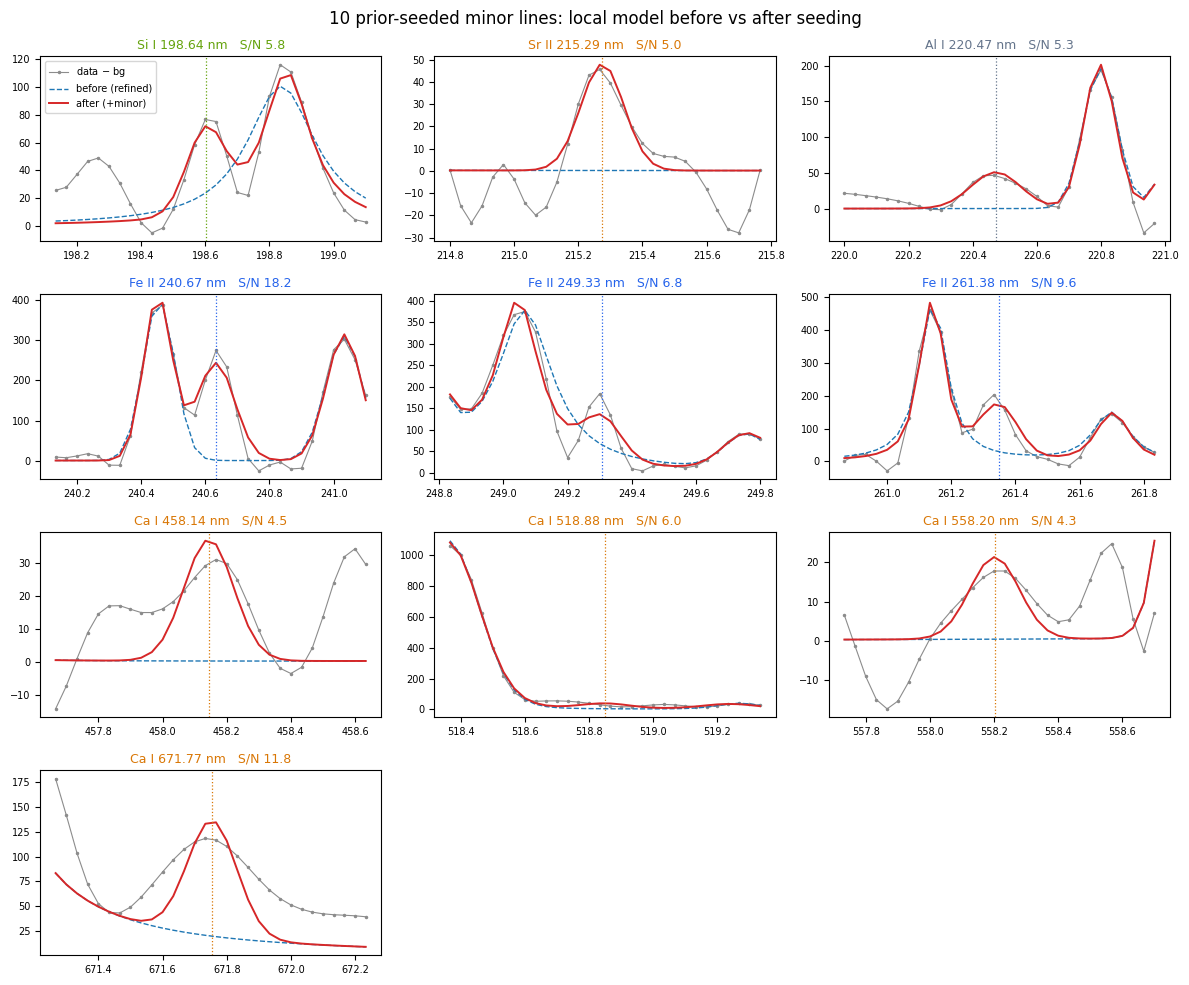

In [13]:
# each accepted minor line: local model BEFORE seeding (refined) vs AFTER (final)
yb    = y - final["background"]
noise = PeakyFinder._noise_scale_local(yb)
m_ref = multi_voigt(x, np.ravel(refined["sorted_parameter_array"][:, :4]))
m_fin = multi_voigt(x, np.ravel(final["sorted_parameter_array"][:, :4]))
added = sorted([r for r in records if r["action"] == "added"],
               key=lambda r: r["wavelength_db"])

ncol = 3
nrow = int(np.ceil(len(added) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.5 * nrow))
axf = np.atleast_1d(axs).ravel()
for ax, r in zip(axf, added):
    c = r["center"]
    block_color = element_block_color(r["element"])
    w = (x > c - 0.5) & (x < c + 0.5)
    ax.plot(x[w], yb[w], color="0.55", lw=0.8, marker=".", ms=3, label="data $-$ bg")
    ax.plot(x[w], m_ref[w], "C0--", lw=1.0, label="before (refined)")
    ax.plot(x[w], m_fin[w], "C3-", lw=1.4, label="after (+minor)")
    ax.axvline(c, color=block_color, ls=":", lw=0.9)
    stage = "I" if r["stage"] == 1 else "II"
    ax.set_title(f"{r['element']} {stage} {r['wavelength_db']:.2f} nm   S/N {r['snr']:.1f}",
                 fontsize=9, color=block_color)
    ax.tick_params(labelsize=7)
for ax in axf[len(added):]:
    ax.set_visible(False)
axf[0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"{len(added)} prior-seeded minor lines: local model before vs after seeding",
             fontsize=12)
fig.tight_layout();

### Residual healed, window by window

Every seeded window's residual drops from the refined fit to `final`, and none
gets worse. The strong-line windows (Fe II 249 next to Fe II 248.9, Ca I 671.8
on the wing of Li I 670.8) keep a larger residual because a bright neighbour
dominates them, but even there the direction is unambiguous. The last two rows
aggregate over the union of windows.

In [14]:
# residual in each seeded window: refined (before) vs final (after)
def _rms(v):
    return float(np.sqrt(np.mean(v ** 2)))

print(f"{'line':>10}  {'refined':>14}  {'+minor':>14}")
print(f"{'':>10}  {'RMS  misfit':>14}  {'RMS  misfit':>14}")
for r in added:
    w = (x > r["center"] - 0.4) & (x < r["center"] + 0.4)
    rr, rf = yb[w] - m_ref[w], yb[w] - m_fin[w]
    stage = "I" if r["stage"] == 1 else "II"
    print(f"{r['element'] + ' ' + stage:>4} {r['wavelength_db']:7.2f}  "
          f"{_rms(rr):7.1f} {100 * np.mean(np.abs(rr) > 2 * noise[w]):4.0f}%  "
          f"{_rms(rf):7.1f} {100 * np.mean(np.abs(rf) > 2 * noise[w]):4.0f}%")

win = np.zeros_like(x, bool)
for r in added:
    win |= np.abs(x - r["center"]) < 0.4
print("-" * 42)
for name, mm in [("refined", m_ref), ("+minor", m_fin)]:
    res = yb[win] - mm[win]
    print(f"{'all windows ' + name:>18}  {_rms(res):7.1f} "
          f"{100 * np.mean(np.abs(res) > 2 * noise[win]):4.0f}%")

      line         refined          +minor
               RMS  misfit     RMS  misfit
Si I  198.64     26.4   29%     18.6   12%
Sr II  215.29     20.7   12%     10.5    0%
Al I  220.47     21.2   12%      6.8    0%
Fe II  240.67     89.6   21%     22.8    4%
Fe II  249.33     49.4   25%     28.6    4%
Fe II  261.38     61.2   25%     28.8    8%
Ca I  458.14     17.8    0%     10.2    0%
Ca I  518.88     23.9   42%     17.7   25%
Ca I  558.20     13.5    8%     10.7    8%
Ca I  671.77     57.9   62%     27.8   33%
------------------------------------------
all windows refined     45.0   24%
all windows +minor     19.9   10%


### The same improvement through `plot_spectrum_overview`

Most of the seeded lines live in the UV below 265 nm (Si, Sr, Al, Fe). Running
the overview on the refined fit and then on `final` over that same window, the
residual panel's out-of-band spikes at the seeded positions collapse into the
±2σ band — the improvement the per-window table quantifies, seen in the same
three-panel view used for the blind fit.

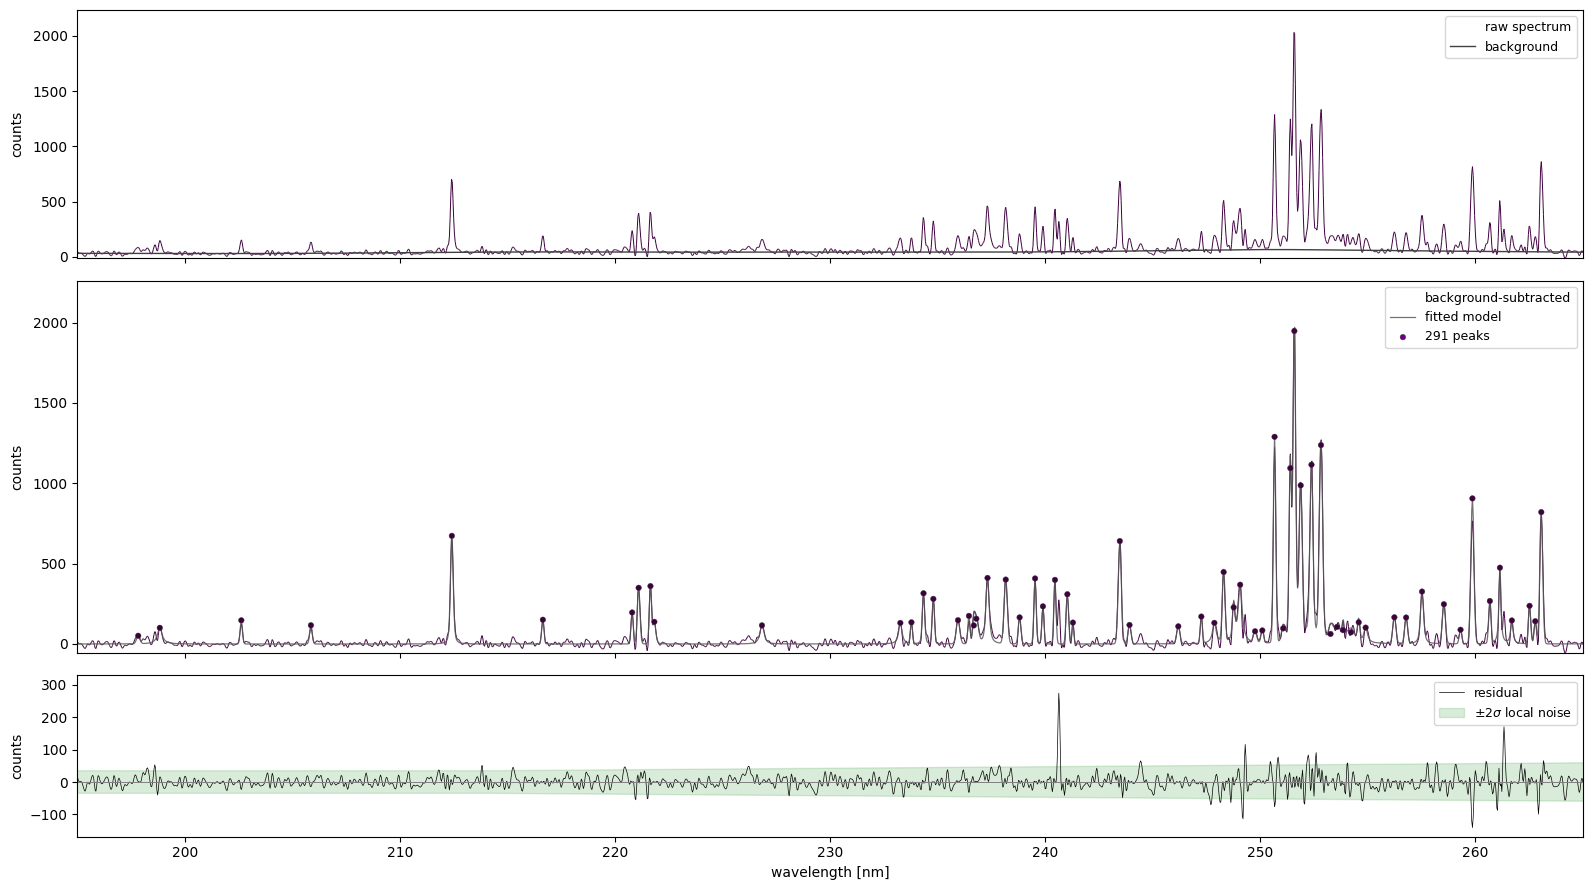

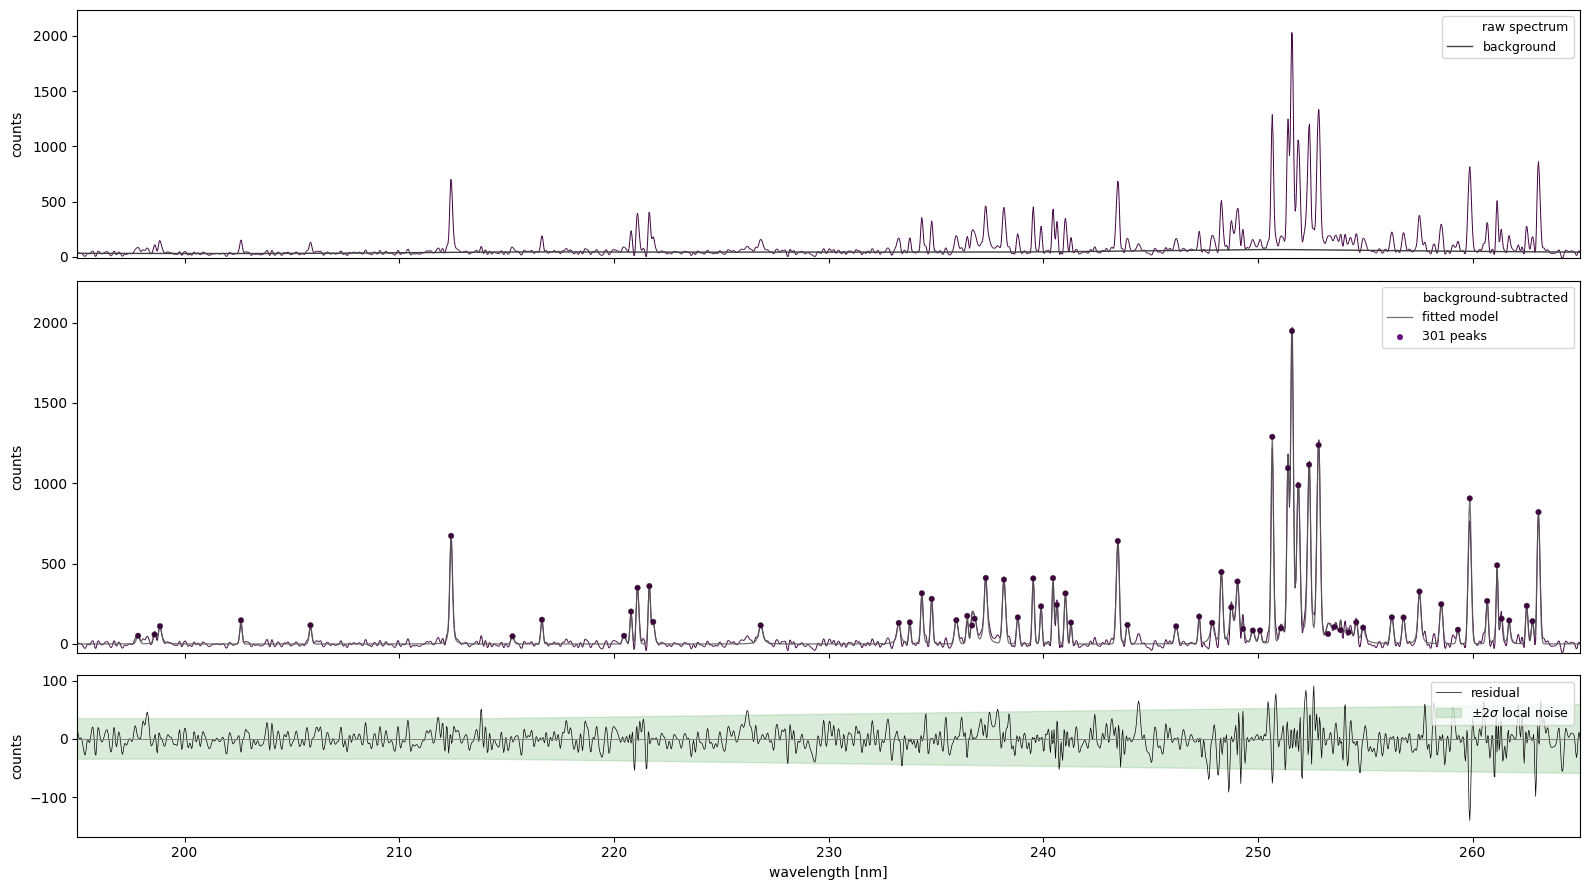

In [15]:
# same window, through the standard overview: before seeding, then after.
# the out-of-band residual spikes at the seeded positions collapse into the band.
plot_spectrum_overview(x, y, refined, xlim=(195, 265))   # before
plot_spectrum_overview(x, y, final,   xlim=(195, 265));   # after

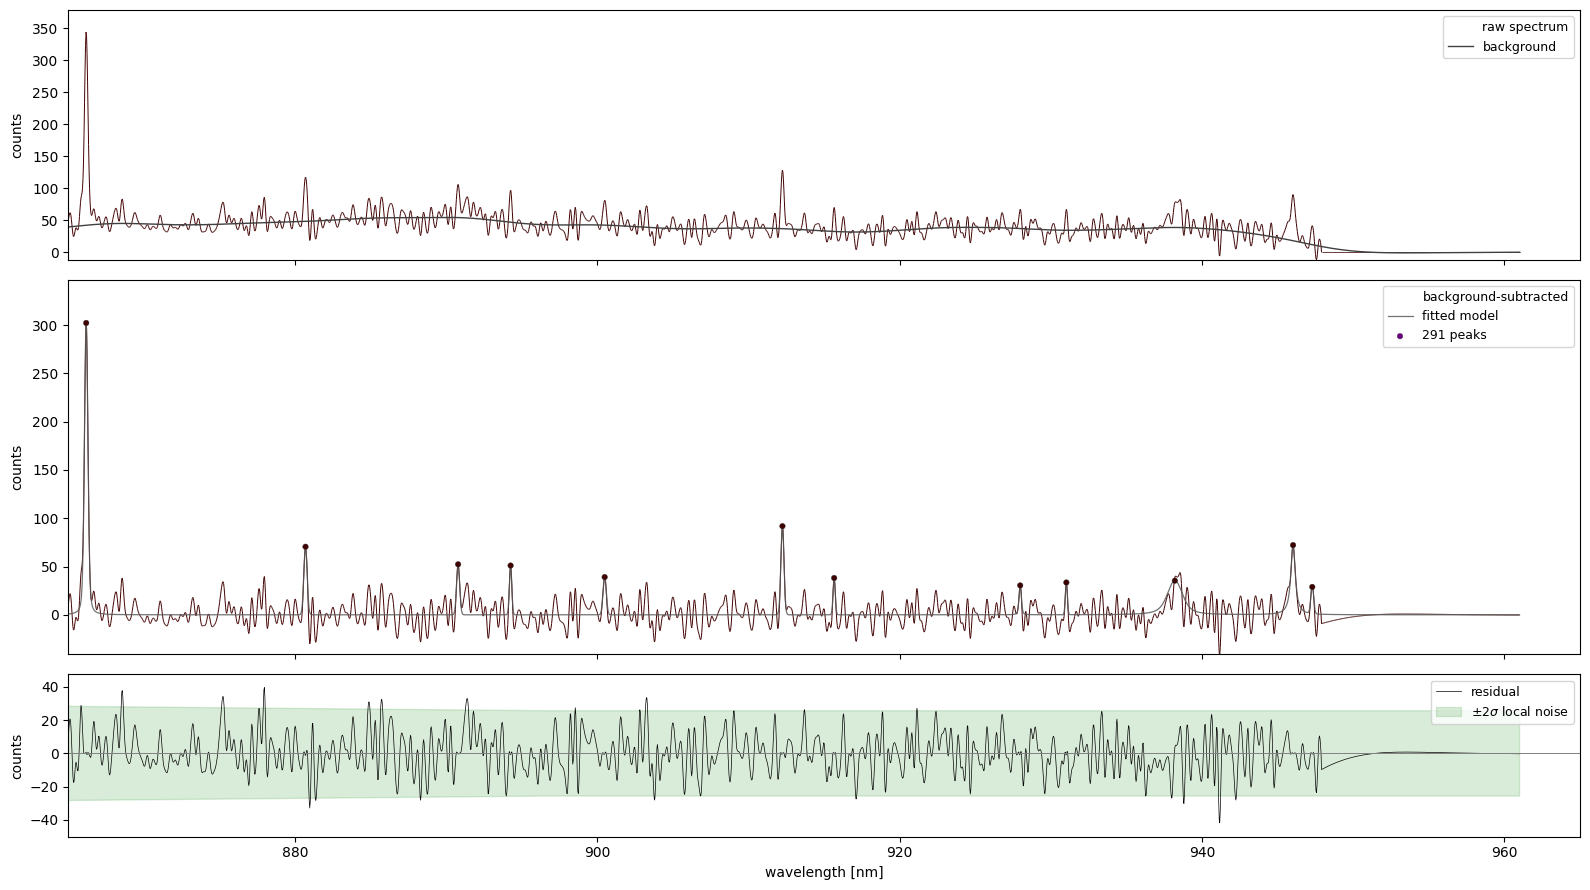

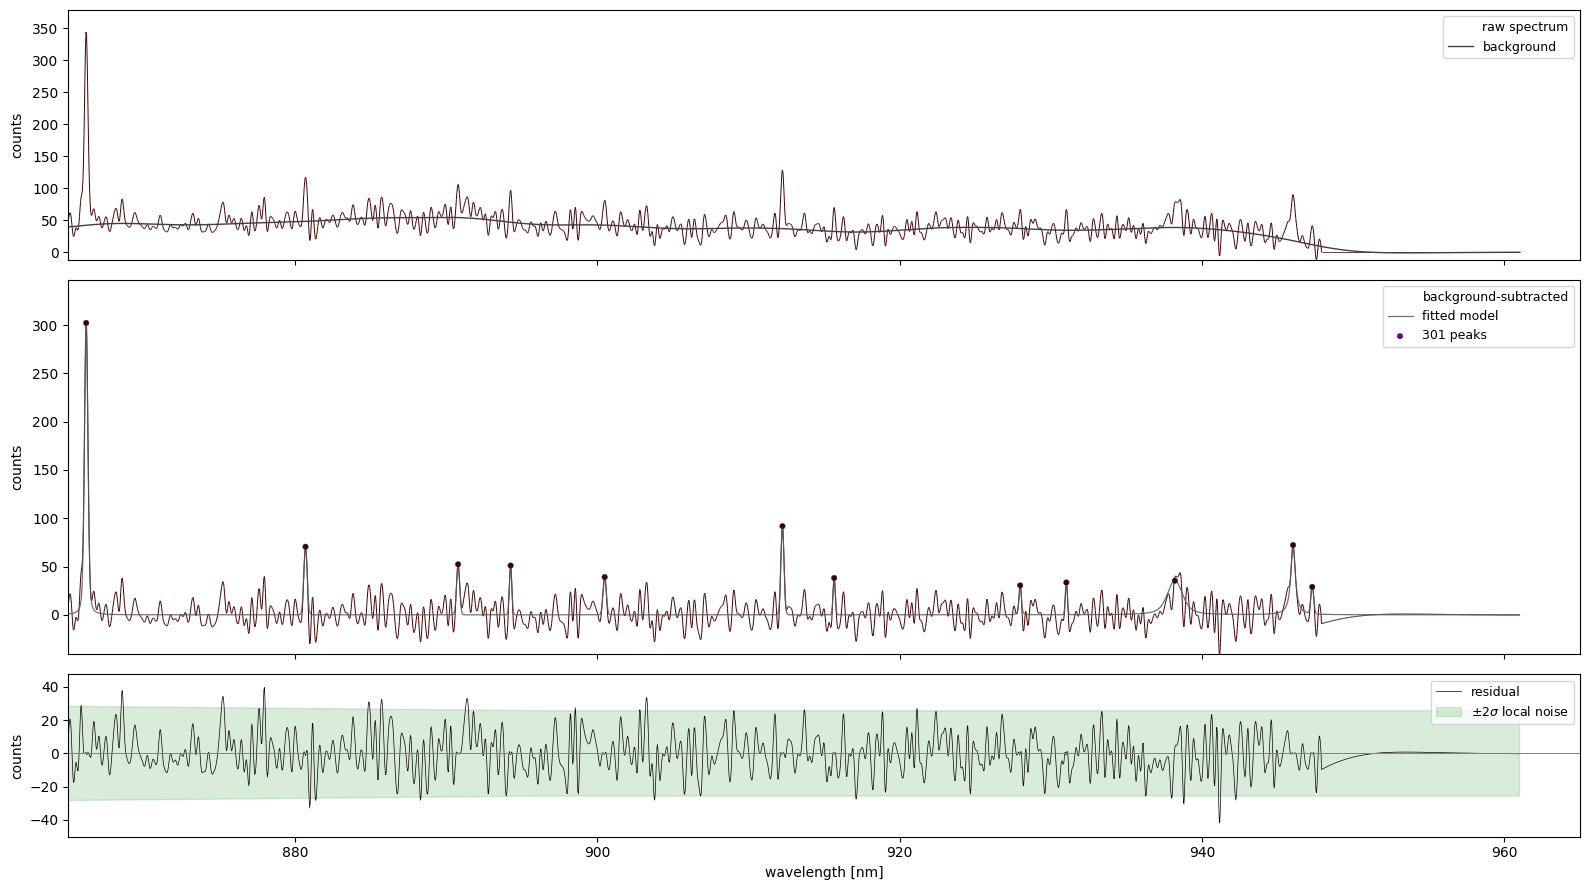

In [16]:
plot_spectrum_overview(x, y, refined, xlim=(865, 965))   # before
plot_spectrum_overview(x, y, final,   xlim=(865, 965));   # after

### The final model over the full span

`plot_spectrum_overview` on `final` — the culmination of blind fit → refinement
→ prior-seeded minor lines. The residual panel is now dominated by the few
strong self-absorbed lines, where the stored **symmetric proxy** (observed area,
plain Voigt) cannot follow the flat top — a storage choice, since the attenuated
model actually fit these lines well and the emission area + τ are kept in the
decision record ([docs/fit_pipeline.md §5a](../docs/fit_pipeline.md)). The rest
of the span, seeded minor lines included, sits inside the ±2σ noise band.

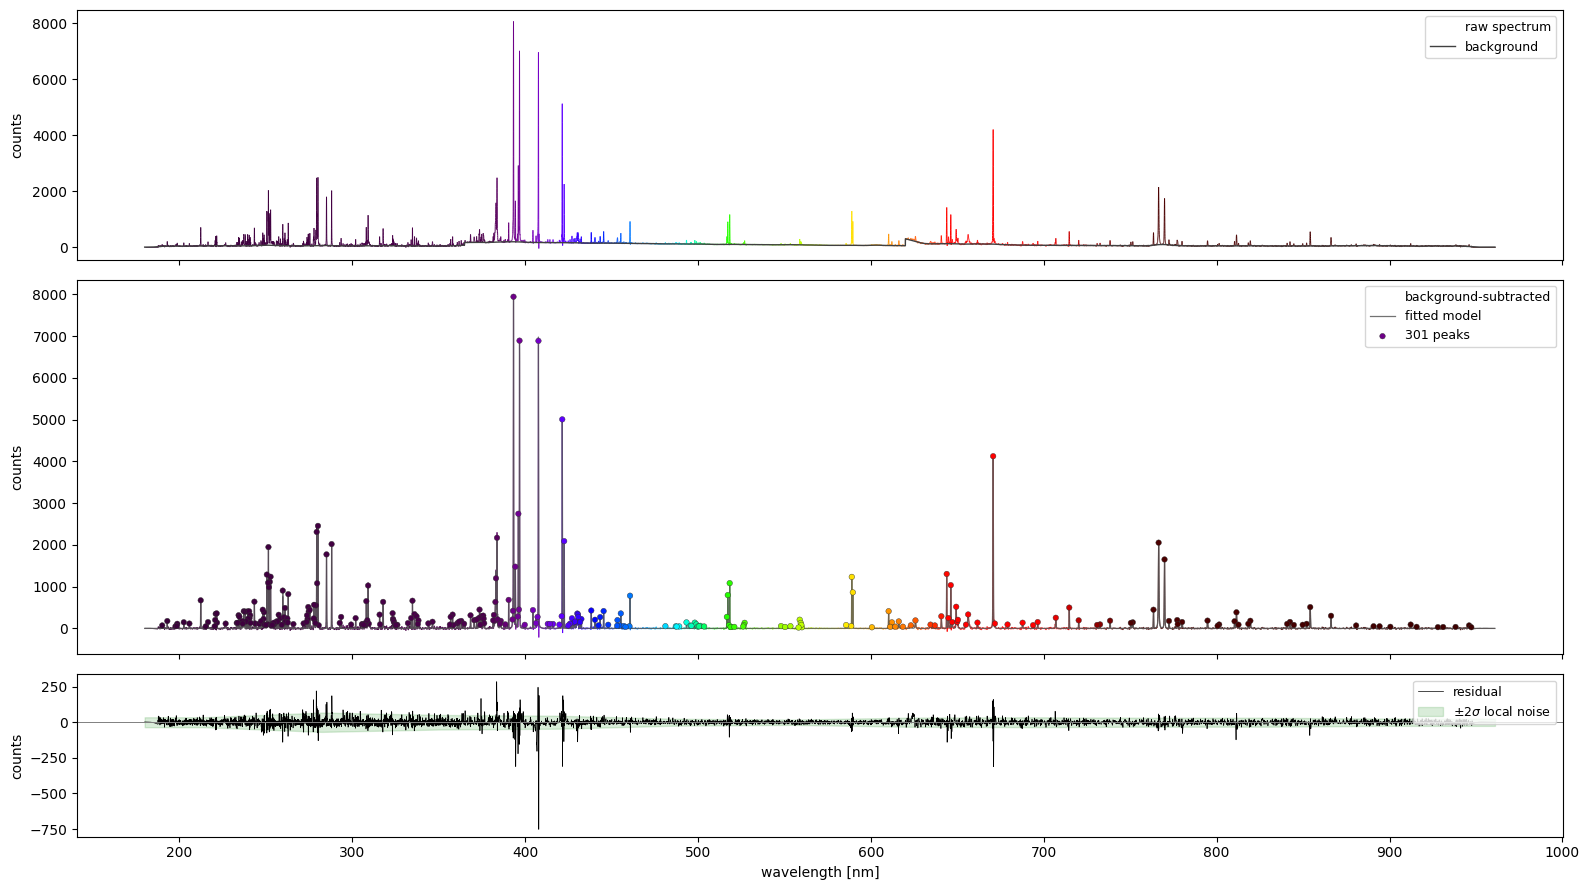

In [17]:
fig, axs = plot_spectrum_overview(x, y, final)

## Element-agnostic residual recovery

Significant positive residual peaks that survive the blind fit, refinement, and
the Boltzmann seeder are usually real lines the seeder could not predict — most
often a line-rich element (Fe) whose per-stage Boltzmann scale fails the trust
gate. `recover_residual_lines` fits each significant positive residual maximum
(*prominence* above the local residual baseline > 4σ, with a free pedestal so a
broad ledge is not mistaken for lines) as a new component from the data alone;
the whole-pattern indexer then identifies it. The asymmetric-merged
self-absorption zones are excluded — their symmetric proxy leaves a core-shaped
residual by design, and recovering there would re-split the merge.

In [18]:
from alibz import recover_residual_lines
from alibz.utils.voigt import voigt_width

# exclude the asymmetric-merged self-absorption zones (as the pipeline does):
# their symmetric table proxy leaves a core-shaped residual by design
sa_zones = [(float(d["params_asym"][1]),
             1.5 * max(float(voigt_width(max(d["params_asym"][2], 1e-6),
                                         max(d["params_asym"][3], 1e-6))), 0.15))
            for d in decisions
            if d.get("action") == "merge"
            and str(d.get("verdict", "")).startswith("asymmetric")
            and d.get("params_asym") is not None]

final_rec, recovered = recover_residual_lines(x, y, final, exclude=tuple(sa_zones))
added_rec = [r for r in recovered if r["action"] == "added"]
print(f"{final['sorted_parameter_array'].shape[0]} -> "
      f"{final_rec['sorted_parameter_array'].shape[0]} peaks  "
      f"({len(added_rec)} recovered, {len(sa_zones)} SA zones excluded)")
for r in sorted(added_rec, key=lambda r: r["center"])[:20]:
    print(f"  {r['center']:9.3f}  area={r['area']:8.1f}  snr={r['snr']:6.1f}  "
          f"dBIC={r['delta_bic']:8.1f}")

301 -> 317 peaks  (16 recovered, 0 SA zones excluded)
    277.604  area=    26.7  snr=  10.0  dBIC=    21.0
    279.264  area=    38.8  snr=  14.4  dBIC=    32.5
    288.217  area=    55.1  snr=  17.1  dBIC=    44.2
    374.530  area=    44.9  snr=  15.7  dBIC=    79.3
    383.583  area=    81.8  snr=  28.6  dBIC=   132.5
    397.136  area=    22.9  snr=   9.6  dBIC=    51.8
    407.550  area=   102.7  snr=  38.3  dBIC=   551.3
    408.108  area=    33.2  snr=  15.0  dBIC=   125.7
    421.873  area=    20.4  snr=  10.4  dBIC=    57.7
    422.287  area=    20.7  snr=  10.6  dBIC=    53.3
    516.964  area=     6.6  snr=   7.3  dBIC=    16.7
    518.274  area=    59.3  snr=  65.8  dBIC=   132.7
    589.288  area=     7.2  snr=  10.2  dBIC=    42.3
    670.820  area=   256.6  snr= 123.8  dBIC=   671.0
    671.230  area=    28.6  snr=  14.9  dBIC=    94.2
    706.617  area=    16.7  snr=  10.5  dBIC=    50.8


## Composition, detection, and confounders

`analyze_spectrum` is the packaged one-call pipeline — the same chain the steps
above walk through (blind fit → refinement → seeded minor lines → residual
recovery) *plus* per-shot Hα nₑ anchoring and two warm-started indexer passes
for composition (a single hand-built indexer pass without the nₑ anchor lands in
the wrong basin). It returns a per-element **detection report** from
`alibz.detections`: significance `z`, independent line support, near-limit upper
bounds, and the true-negative **confounder** test. An element whose *every*
supporting peak could equally be a rival's line — at the largest concentration
that rival's own absent/weak lines allow, scanned over the corpus plasma range —
is demoted to `confounded`. Its abundance is then **resolved**: credited only
its uncontested flux, with the rest reattributed to the rival whose own lines
are present (`resolve_confounded`), so `resolved` — not the raw NNLS `fraction` —
is the defensible number. `confounder_catalog` aggregates the rivals across a
corpus into its operative confounder set (see `docs/development_guide.md`).

In [19]:
from alibz import analyze_spectrum

# the packaged one-call pipeline (fit -> refine -> seed -> recover -> two
# H-alpha-anchored indexer passes -> detection report). Re-runs the whole
# chain from raw x, y so the composition uses the pipeline's careful setup.
a = analyze_spectrum(x, y, "db", n_calls=40, draws=16)
res = a["result"]
print(f"T = {res.temperature:.0f} K   log ne = {res.ne:.2f}   "
      f"r^2 = {res.r_squared:.3f}   "
      f"peaks = {a['final']['sorted_parameter_array'].shape[0]}\n")
# 'resolved' is the true-negative-corrected abundance: a confounded element
# is credited only its uncontested flux, the rest reattributed to its rival
print(f"{'el':>4} {'status':>12} {'fraction':>10} {'resolved':>10} {'z':>6} "
      f"{'lines':>5} {'clear':>5} {'confounder':>10}")
for d in sorted(a["detections"], key=lambda d: -(d["fraction"] or 0)):
    if (d["fraction"] or 0) <= 0:
        continue
    print(f"{d['element']:>4} {d['status']:>12} {d['fraction']:10.5f} "
          f"{d['fraction_resolved']:10.5f} {d['z']:6.1f} {d['n_lines']:5d} "
          f"{d['clear_lines'] if d['clear_lines'] is not None else '':>5} "
          f"{d.get('confounder') or '':>10}")

T = 5955 K   log ne = 17.54   r^2 = 0.732   peaks = 356

  el       status   fraction   resolved      z lines clear confounder
  Si     detected    0.75133    0.75133   10.9    17    17         Bi
  Fe     detected    0.09170    0.09638    6.5    56    48         Eu
  Al         weak    0.05430    0.05430    1.2     9     9         Mn
  Ti     marginal    0.03891    0.03891    2.6    22    21         Mn
   K     detected    0.02213    0.02213    8.3     2     2           
  Li     detected    0.01550    0.01550    8.8     3     3           
  Mg  single-line    0.01020    0.01020    7.3     1     1           
  Be   confounded    0.00468    0.00000    8.2     1     0         Fe
  Rb     detected    0.00386    0.00386    6.8     2     2           
  Na         weak    0.00261    0.00261    1.7     2     3           
  Ca         weak    0.00208    0.00208    2.0     5     8           
  Sr     detected    0.00153    0.00153    6.3     6     7           
  Ba     detected    0.00069    0

In [20]:
from alibz import confounder_catalog

cat = confounder_catalog(a["detections"])
if cat:
    print("confounder pairs on this spectrum (element <- viable rival):")
    for (el, rival), n in cat.most_common():
        print(f"  {el} <- {rival}")
else:
    print("no confounded elements here — every detection has an independent "
          "supporting line the rivals cannot cover")
print("\nacross a corpus, confounder_catalog over ALL detections gives the "
      "operative confounder set for the instrument + (T, ne) range")

confounder pairs on this spectrum (element <- viable rival):
  Be <- Fe
  Al <- Mn
  Si <- Bi
  Ti <- Mn
  Fe <- Eu
  Ba <- Rb

across a corpus, confounder_catalog over ALL detections gives the operative confounder set for the instrument + (T, ne) range
